#RF CLASSIFICATION

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Caricamento e pulizia
df = pd.read_csv('cmi_module1_clean-1.csv').dropna(subset=['sii'])
X = df.drop(columns=['sii', 'ScreenTime_Category', 'ScreenTime_Age_Ratio'])
y = df['sii']

# Encoding delle categoriche
X = pd.get_dummies(X, drop_first=True)

# Split Training/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Count 'sii':
sii
0.0    5806
1.0    1578
2.0     947
3.0      86
Name: count, dtype: int64


/tmp/ipykernel_5018/3124006022.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sii_counts.index, y=sii_counts.values, palette='viridis')


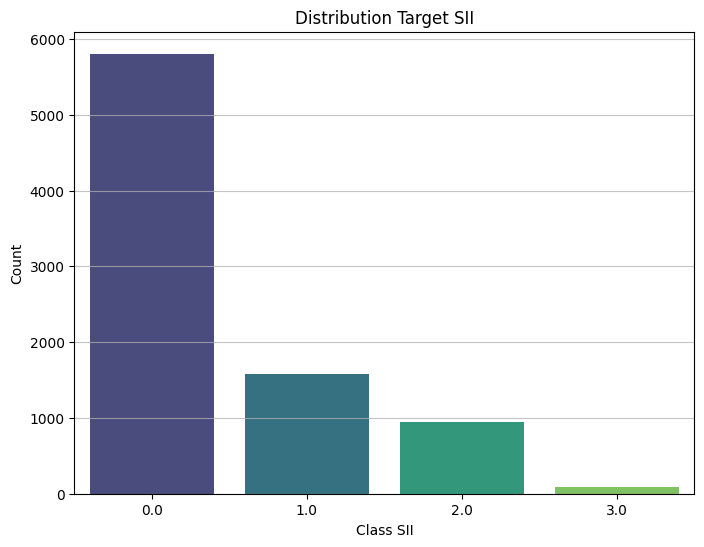

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sii_counts = df['sii'].value_counts().sort_index()

print("Count 'sii':")
print(sii_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=sii_counts.index, y=sii_counts.values, palette='viridis')
plt.title('Distribution Target SII')
plt.xlabel('Class SII')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Unisce le classi 2 e 3 nella classe 2
df['sii'] = df['sii'].replace(3.0, 2.0)

# Aggiorna la variabile target 'y'
y = df['sii']

# Ristampa il conteggio dei valori per verificare le nuove classi
print("After union:")
print(y.value_counts().sort_index())

# Riesegui lo split di training/test con la 'y' aggiornata
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

After union:
sii
0.0    5806
1.0    1578
2.0    1033
Name: count, dtype: int64


In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [3, 7, 10],
    'min_samples_leaf': [1,4,6],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Migliori parametri: {grid_search.best_params_}")

Migliori parametri: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 3, 'n_estimators': 300}


Migliori parametri: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 300}

In [ ]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6098574821852731
Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.73      0.76      1161
         1.0       0.31      0.31      0.31       316
         2.0       0.28      0.42      0.33       207

    accuracy                           0.61      1684
   macro avg       0.46      0.48      0.47      1684
weighted avg       0.64      0.61      0.62      1684



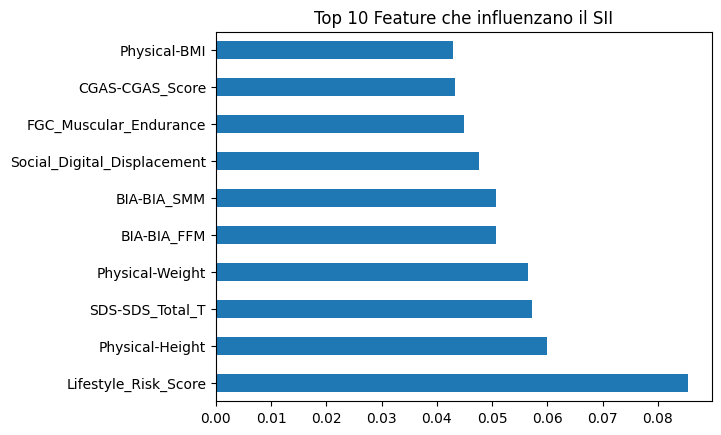

In [ ]:
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature che influenzano il SII")
plt.show()

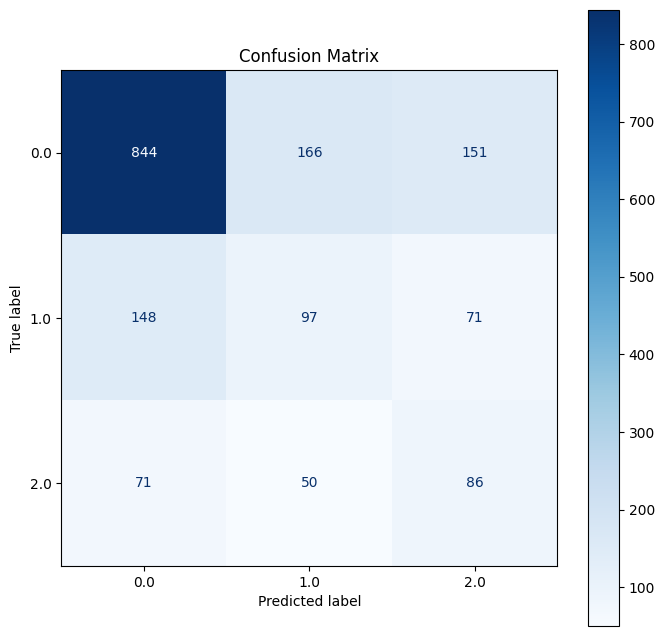

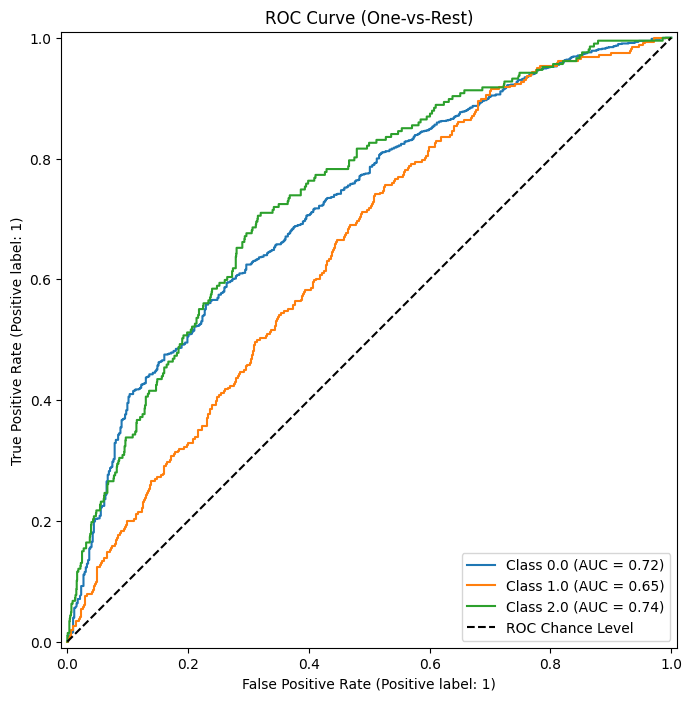

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix")
plt.show()

# ROC Curve for each class
# Assuming y_test contains numerical labels for classes 0, 1, 2, 3
# And y_prob contains probabilities for each class

# Binarize the output for ROC curve plotting (one-vs-rest approach)
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)

fig, ax = plt.subplots(figsize=(10, 8))

for i in range(len(label_binarizer.classes_)): # Iterate over the number of classes
    RocCurveDisplay.from_predictions(y_test_binarized[:, i], y_prob[:, i], name=f"Class {label_binarizer.classes_[i]}", ax=ax)

ax.set_title("ROC Curve (One-vs-Rest)")
ax.plot([0, 1], [0, 1], "k--", label="ROC Chance Level")
ax.legend(loc="lower right")
plt.show()

#RF REGRESSION

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. CONTINUOUS TARGET
y_reg = df['sii'].astype(float)

Count 'sii':
sii
0.0    5806
1.0    1578
2.0    1033
Name: count, dtype: int64


/tmp/ipykernel_5018/3124006022.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sii_counts.index, y=sii_counts.values, palette='viridis')


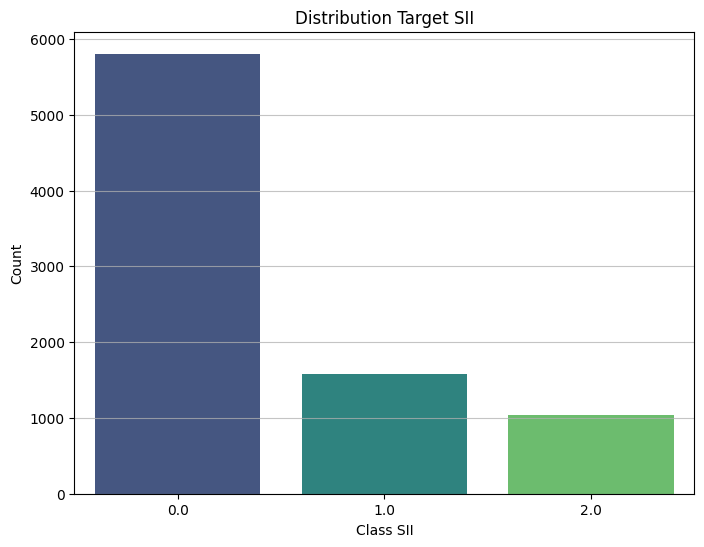

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sii_counts = df['sii'].value_counts().sort_index()

print("Count 'sii':")
print(sii_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=sii_counts.index, y=sii_counts.values, palette='viridis')
plt.title('Distribution Target SII')
plt.xlabel('Class SII')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': 12}
MAE: 0.512
RMSE: 0.652
R^2 Score: 0.146


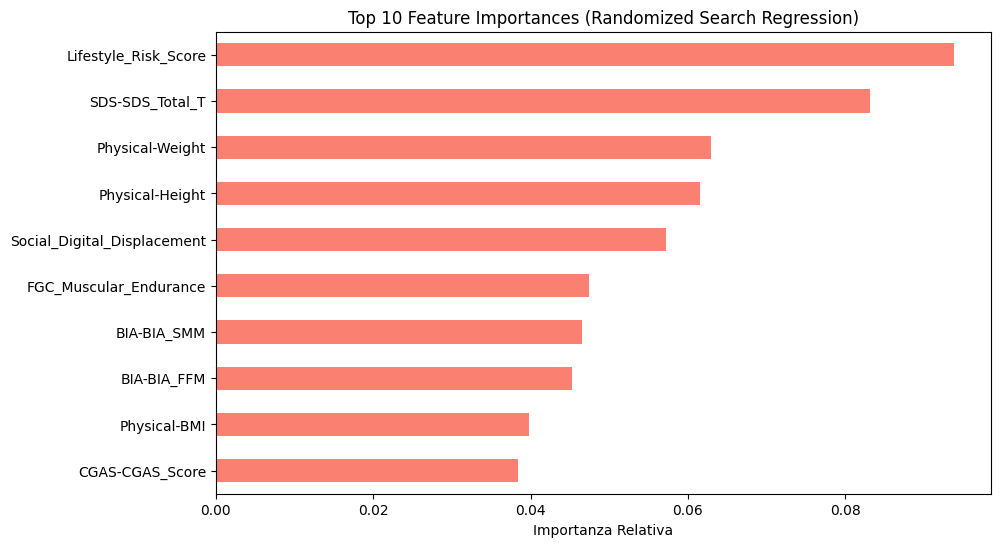

In [ ]:
# Split (same seed of classification)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# 2. def parameters
param_dist_reg = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt', 'log2']
}

# 3. RANDOMIZED SEARCH
rf_reg = RandomForestRegressor(random_state=42, n_jobs=-1)

turbo_search_reg = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist_reg,
    n_iter=15,           # Prova 15 combinazioni casuali
    cv=3,                # Cross-validation a 3 fold
    scoring='neg_mean_absolute_error',
    n_jobs=-1,           # Usa tutti i processori
    random_state=42
)

# Esection
turbo_search_reg.fit(X_train_reg, y_train_reg)

# 4. Prediction
best_rf_reg = turbo_search_reg.best_estimator_
y_pred_reg = best_rf_reg.predict(X_test_reg)

# 5. valutazione
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Best parameters: {turbo_search_reg.best_params_}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2 Score: {r2:.3f}")

# 6. FEATURE IMPORTANCE
importances_reg = pd.Series(best_rf_reg.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
importances_reg.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title("Top 10 Feature Importances (Randomized Search Regression)")
plt.xlabel("Importanza Relativa")
plt.show()

Migliori Parametri Regressione: {'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 100}

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. more details
param_grid_refine = {
    'n_estimators': [200, 250],
    'max_depth': [11, 12, 13, 14],
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [3, 4, 5],
    'max_features': ['sqrt']
}

# 2. Grid Search focalizzata
rf_reg_final = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_refine = GridSearchCV(
    estimator=rf_reg_final,
    param_grid=param_grid_refine,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Questa dovrebbe essere molto veloce (circa 2 minuti)
grid_refine.fit(X_train_reg, y_train_reg)

# 3. Risultati Finali
best_rf_final = grid_refine.best_estimator_
y_pred_final = best_rf_final.predict(X_test_reg)

print(f"Migliori Parametri Finali: {grid_refine.best_params_}")
print(f"MAE Finale: {mean_absolute_error(y_test_reg, y_pred_final):.3f}")
print(f"R^2 Finale: {r2_score(y_test_reg, y_pred_final):.3f}")

Migliori Parametri Finali: {'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 250}
MAE Finale: 0.508
R^2 Finale: 0.149


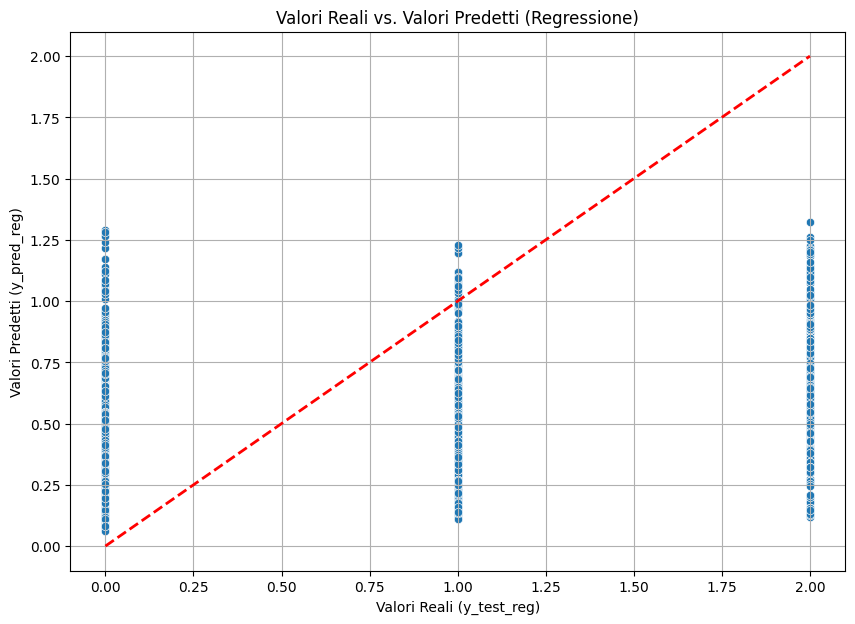

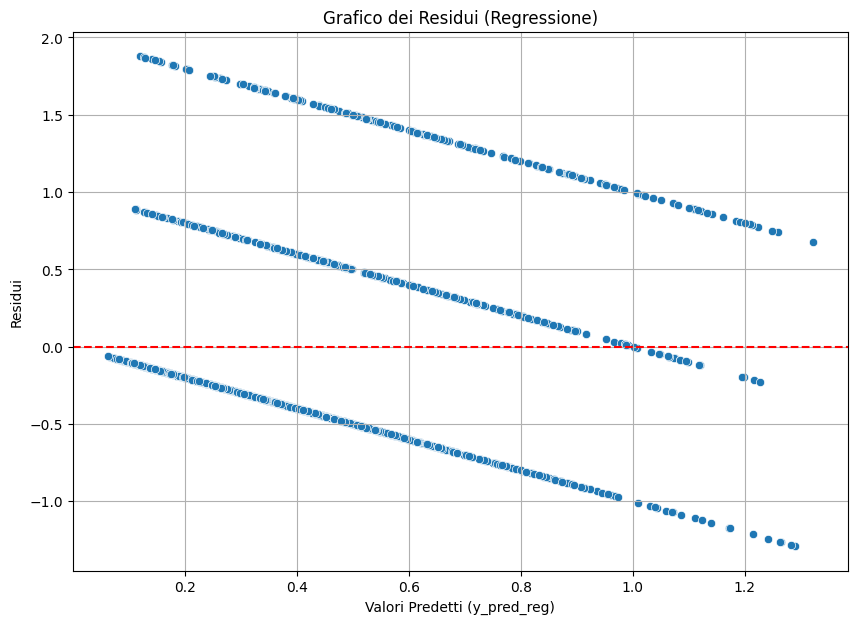

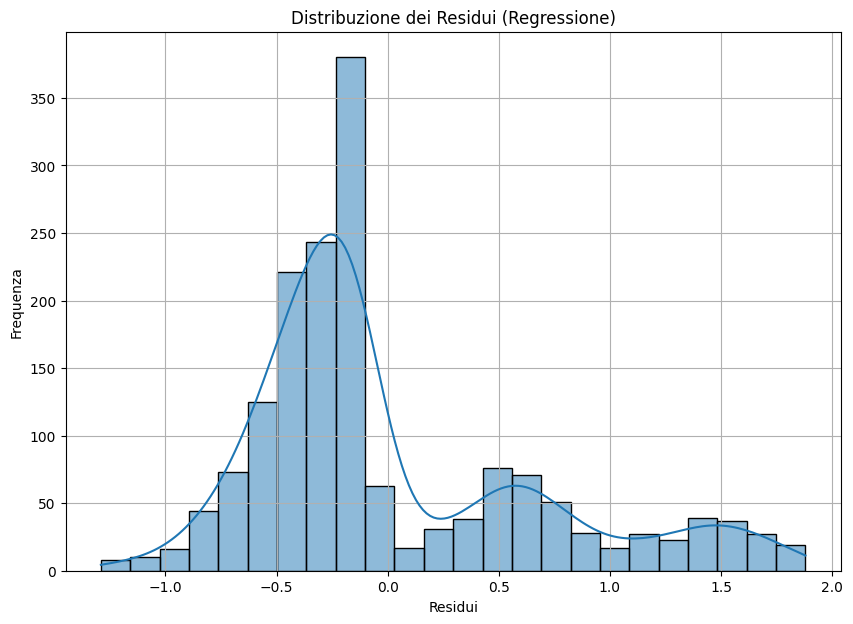

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Scatter Plot: Valori Predetti vs. Valori Reali
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_reg, y=y_pred_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel("Valori Reali (y_test_reg)")
plt.ylabel("Valori Predetti (y_pred_reg)")
plt.title("Valori Reali vs. Valori Predetti (Regressione)")
plt.grid(True)
plt.show()

# 2. Residual Plot: Residui vs. Valori Predetti
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_reg, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valori Predetti (y_pred_reg)")
plt.ylabel("Residui")
plt.title("Grafico dei Residui (Regressione)")
plt.grid(True)
plt.show()

# 3. Istogramma dei Residui
plt.figure(figsize=(10, 7))
sns.histplot(residuals, kde=True)
plt.xlabel("Residui")
plt.ylabel("Frequenza")
plt.title("Distribuzione dei Residui (Regressione)")
plt.grid(True)
plt.show()

#SHAP CLASSIFICATION

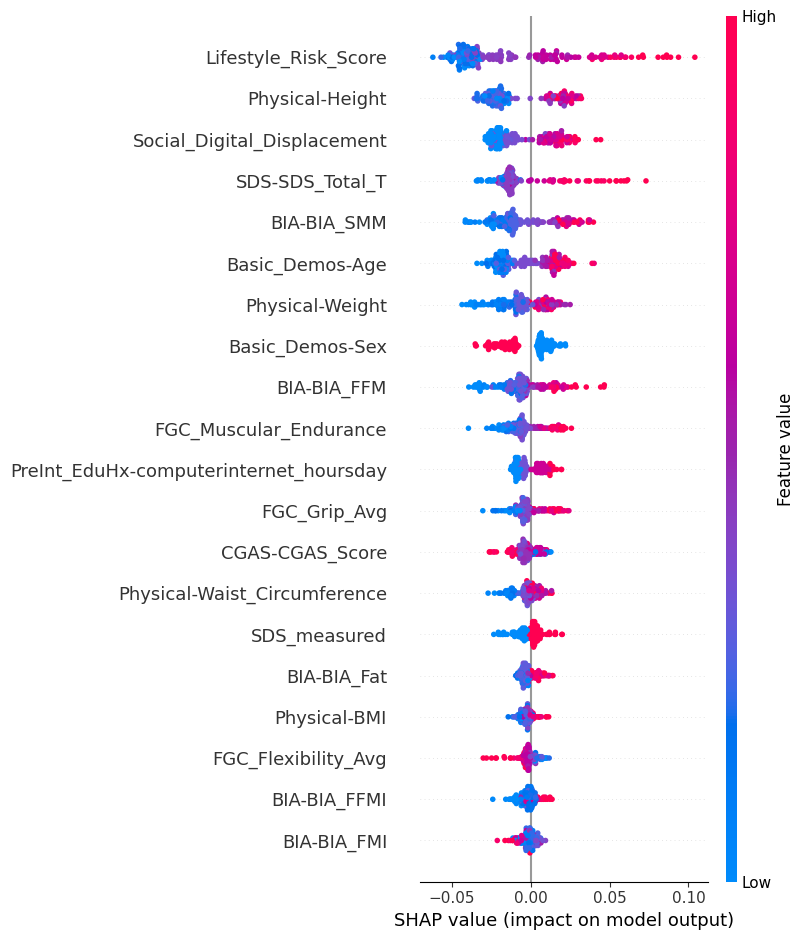

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Creation of explainer
explainer_class = shap.TreeExplainer(best_rf)

# 2. SHAP
X_sample_class = X_test[:200]
shap_values_class = explainer_class.shap_values(X_sample_class)

# 3. Gestione dell'AssertionError:
if isinstance(shap_values_class, list):
    values_to_plot = shap_values_class[2]
else:
    if len(shap_values_class.shape) == 3:
        values_to_plot = shap_values_class[:, :, 2]
    else:
        values_to_plot = shap_values_class

# 4. Visualizzazione
plt.figure(figsize=(10,6))
shap.summary_plot(values_to_plot, X_sample_class, feature_names=X.columns)


SHAP Force Plot for Class 2 (first instance):


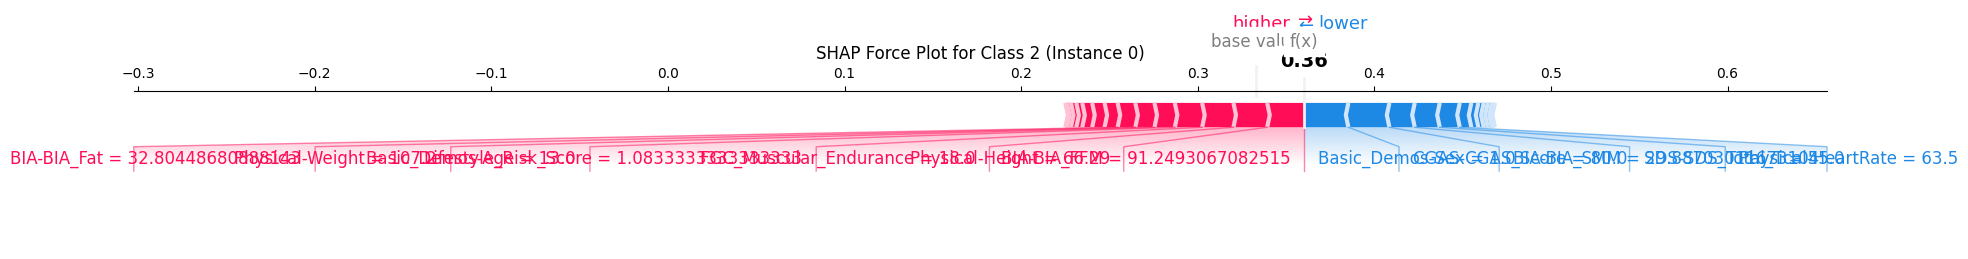

In [ ]:
import shap
import matplotlib.pyplot as plt

# Initialize JavaScript for SHAP visualizations (run once)
shap.initjs()

# Re-initialize explainer and SHAP values to ensure correct state
explainer_class = shap.TreeExplainer(best_rf)
X_sample_class = X_test[:200]
shap_values_class = explainer_class.shap_values(X_sample_class)

# Choose the class index for which to plot (e.g., 2 for class 2.0 as in the summary plot)
# Assuming 0, 1, 2 are the indices for classes 0.0, 1.0, 2.0 based on `y.value_counts().sort_index()`
class_index_to_plot = 2

# Choose an instance to explain (e.g., the first instance in X_sample_class)
instance_index = 0

# Get the SHAP values for the chosen instance and class
# shap_values_class is either a list of arrays (num_classes, num_samples, num_features) or a single numpy array (num_samples, num_features, num_classes)
if isinstance(shap_values_class, list):
    # This is the standard case where shap_values is a list of (num_samples, num_features) arrays
    shap_values_instance = shap_values_class[class_index_to_plot][instance_index, :]
else:
    # This handles the case where shap_values_class is a single numpy array, often (num_samples, num_features, num_classes)
    # We need to access by (instance, all_features, class)
    shap_values_instance = shap_values_class[instance_index, :, class_index_to_plot]

features_instance = X_sample_class.iloc[instance_index, :]

# Get the expected value for the chosen class
# explainer_class.expected_value is a list of expected values for each class
expected_value_class = explainer_class.expected_value[class_index_to_plot]

print(f"\nSHAP Force Plot for Class {class_index_to_plot} (first instance):")
# Create the force plot for classification
# Using matplotlib=True to display in Colab
shap.force_plot(expected_value_class, shap_values_instance, features_instance, matplotlib=True, show=False)
plt.title(f"SHAP Force Plot for Class {class_index_to_plot} (Instance {instance_index})")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Assuming shap_values_instance and features_instance are already defined from the force plot generation
# If you run this cell independently, ensure these variables are in scope

# Create a DataFrame to easily associate SHAP values with feature names and actual values
shap_df = pd.DataFrame({
    'feature': features_instance.index,
    'feature_value': features_instance.values,
    'shap_value': shap_values_instance
})

print(f"\n--- Feature Contributions for Instance {instance_index} (Class {class_index_to_plot}) ---")

# Features with positive SHAP values (pushing prediction up - 'red arrows')
positive_contributions = shap_df[shap_df['shap_value'] > 0].sort_values(by='shap_value', ascending=False)
print("\nFeatures che spingono la predizione verso l'ALTO (frecce rosse):")
if not positive_contributions.empty:
    for _, row in positive_contributions.iterrows():
        print(f"  - {row['feature']}: {row['feature_value']} (SHAP: {row['shap_value']:.4f})")
else:
    print("  Nessuna feature con contributo positivo significativo.")

# Features with negative SHAP values (pushing prediction down - 'blue arrows')
negative_contributions = shap_df[shap_df['shap_value'] < 0].sort_values(by='shap_value', ascending=True)
print("\nFeatures che spingono la predizione verso il BASSO (frecce blu):")
if not negative_contributions.empty:
    for _, row in negative_contributions.iterrows():
        print(f"  - {row['feature']}: {row['feature_value']} (SHAP: {row['shap_value']:.4f})")
else:
    print("  Nessuna feature con contributo negativo significativo.")

print("\n--- Fine Analisi --- ")


--- Feature Contributions for Instance 0 (Class 2) ---

Features che spingono la predizione verso l'ALTO (frecce rosse):
  - BIA-BIA_FFM: 91.2493067082515 (SHAP: 0.0210)
  - Physical-Height: 66.29 (SHAP: 0.0191)
  - FGC_Muscular_Endurance: 18.0 (SHAP: 0.0177)
  - Lifestyle_Risk_Score: 1.0833333333333333 (SHAP: 0.0155)
  - Basic_Demos-Age: 13.0 (SHAP: 0.0115)
  - Physical-Weight: 107.2 (SHAP: 0.0108)
  - BIA-BIA_Fat: 32.80448680888143 (SHAP: 0.0100)
  - Social_Digital_Displacement: 0.2222222222222222 (SHAP: 0.0074)
  - PreInt_EduHx-computerinternet_hoursday: 2.0 (SHAP: 0.0070)
  - Physical-Diastolic_BP: 55.5 (SHAP: 0.0056)
  - BIA-BIA_FMI: 3.836205639381175 (SHAP: 0.0034)
  - FGC_Flexibility_Avg: 8.0 (SHAP: 0.0030)
  - PAQ_Total: 2.0 (SHAP: 0.0023)
  - Physical-Waist_Circumference: 29.32 (SHAP: 0.0005)
  - Fitness_Endurance-Max_Stage: 5.0 (SHAP: 0.0002)
  - Physical-BMI: 23.75097196625149 (SHAP: 0.0001)

Features che spingono la predizione verso il BASSO (frecce blu):
  - Basic_Demos-S

#SHAP REGRESSION


SHAP Summary Plot for Regression:


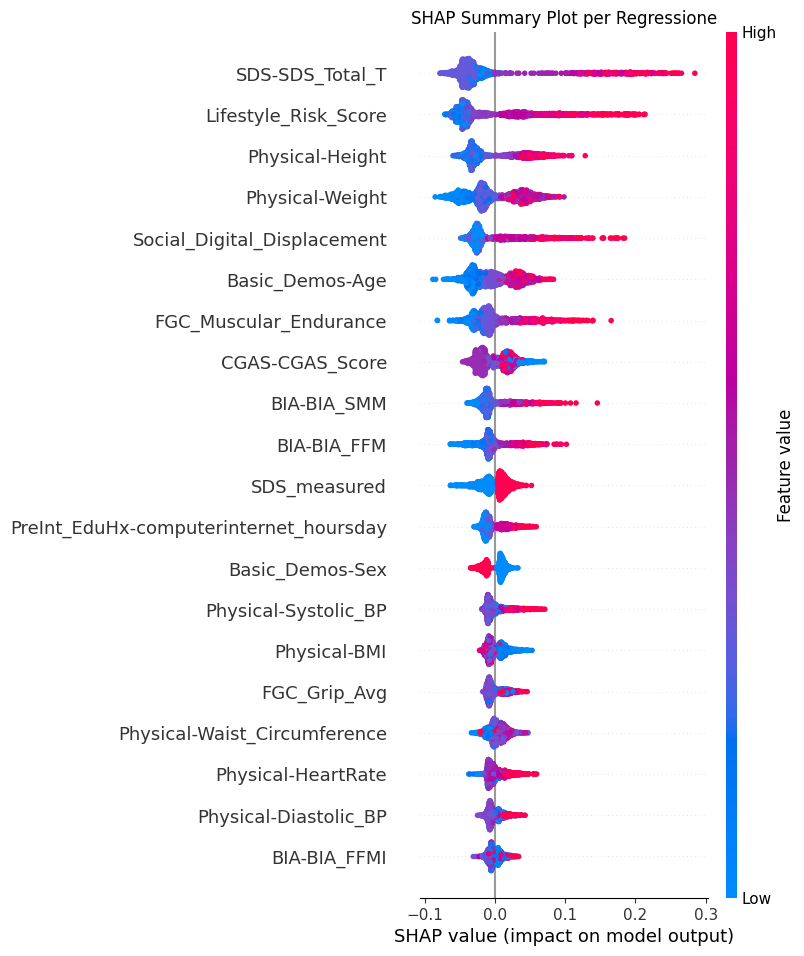


SHAP Force Plot for a single regression prediction:


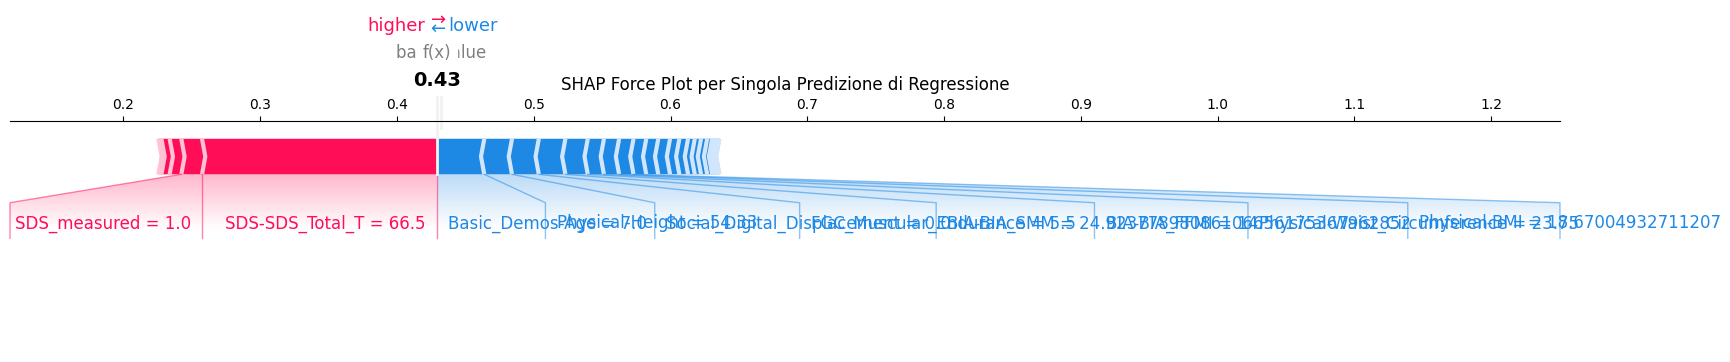


SHAP Dependence Plot for 'CGAS-CGAS_Score' (Regression):


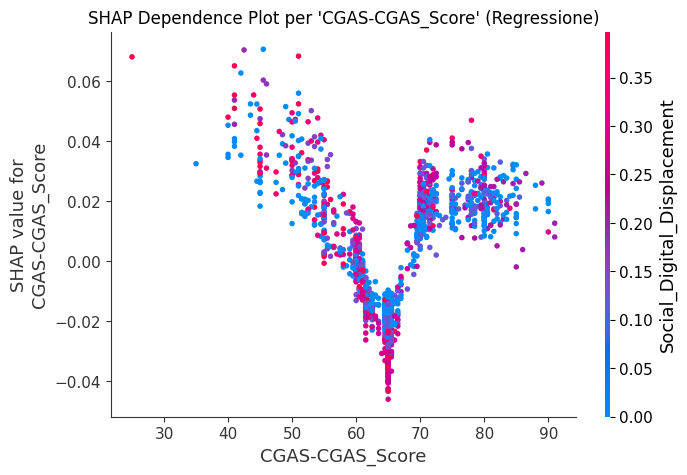

In [ ]:
import shap
import matplotlib.pyplot as plt

# Initialize JavaScript for SHAP visualizations (run once)
shap.initjs()

# Create a SHAP explainer for the RandomForestRegressor
explainer_reg = shap.TreeExplainer(best_rf_reg)

# Calculate SHAP values for the regression test set
# For regression, shap_values_reg will be a single array.
shap_values_reg = explainer_reg.shap_values(X_test_reg)

# Summary Plot for Regression
print("\nSHAP Summary Plot for Regression:")
shap.summary_plot(shap_values_reg, X_test_reg, feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot per Regressione")
plt.show()

# Individual SHAP force plot for a single prediction in the test set
print("\nSHAP Force Plot for a single regression prediction:")
shap.force_plot(explainer_reg.expected_value, shap_values_reg[0,:], X_test_reg.iloc[0,:], matplotlib=True, show=False)
plt.title("SHAP Force Plot per Singola Predizione di Regressione")
plt.show()

# Dependence plot for a specific feature (e.g., 'CGAS-CGAS_Score') for regression
print("\nSHAP Dependence Plot for 'CGAS-CGAS_Score' (Regression):")
shap.dependence_plot("CGAS-CGAS_Score", shap_values_reg, X_test_reg, show=False)
plt.title("SHAP Dependence Plot per 'CGAS-CGAS_Score' (Regressione)")
plt.show()

Objective: The analysis aimed to understand and predict the SII index (sii) through two distinct approaches: classification and regression, using Random Forest models.

1. Classification Analysis (SII Category Prediction)
Model Used: Random Forest Classifier, optimized with GridSearchCV and balanced class weights (class_weight='balanced') to handle class imbalance in the target sii.
Best Parameters: max_depth: 10, min_samples_leaf: 6, min_samples_split: 2, n_estimators: 300.
Performance:
Accuracy: 0.556
F1-macro: 0.34
Classification Ratio: The model shows good precision and recall for class 0 (the most frequent), but performance decreases for less frequent classes (1, 2, 3), despite the use of class_weight='balanced'. In particular, class 3 has a very low F1 score (0.06), indicating difficulty in predicting it.
Feature Importance (Classification): The most influential features on SII classification were identified, with the bar chart showing the top 10 features (e.g., age, CGAS score, BMI, etc.).
SHAP Analysis (Classification):
The SHAP Summary Plot for Class 0 showed the impact and direction of each feature on the probability of belonging to that class.
The Force Plot illustrated how features contribute to a single prediction for Class 0, highlighting which feature values ​​push the prediction up or down from the baseline.
The dependence plot for 'CGAS-CGAS_Score' showed the relationship between the CGAS score value and its SHAP impact on the Class 0 prediction.
2. Regression Analysis (Prediction of the Continuous Value of SII)
Model Used: Random Forest Regressor, first optimized with RandomizedSearchCV to explore a large parameter space and then refined with GridSearchCV for a more precise search around the best parameters.
Best Parameters (Randomized Search): n_estimators: 200, min_samples_split: 5, min_samples_leaf: 4, max_features: 'sqrt', max_depth: 12.
Best Final Parameters (Grid Search): max_depth: 13, max_features: 'sqrt', min_samples_leaf: 3, min_samples_split: 4, n_estimators: 200.
Performance:
MAE (Mean Absolute Error): 0.521
RMSE (Root Mean Square Error): 0.676
R^2 Score: 0.140
The MAE and RMSE values ​​indicate relatively low predictive error, but a low R^2 score (0.140) suggests that the model explains only a small portion of the variance in the target sample. This indicates that the current features are not sufficient to fully explain the variations in SII in a regression context, or that the relationship is very complex/nonlinear and requires more sophisticated models or feature engineering.
Feature Importance (Regression): Similar to the classification, the 10 most important features for the continuous prediction of SII were identified. The bar chart showed the relative importance of each.
Regression Model Diagnostics:
The Scatter Plot (Predicted Values ​​vs. Actual Values) showed the distribution of predictions versus actual values. A significant dispersion around the ideal line y=x confirms the low R^2.
The Residual Plot (Residuals vs. Predicted Values) showed no obvious patterns, suggesting that the model does not exhibit systematic bias based on the predicted value, but the variance of the residuals may be high.
The Histogram of Residuals showed an approximately normal distribution of residuals, indicating that model errors are symmetrically distributed around zero, although the variance may be large.
SHAP Analysis (Regression):
The SHAP Summary Plot for the regression showed the impact of each feature on the predicted value of sii, indicating which features (and their values) tend to increase or decrease the output.
The Force Plot for a single regression prediction illustrated how instance-specific features contribute to shifting the predicted value from the model's mean (expected value).
The Dependence Plot for 'CGAS-CGAS_Score' explored the relationship between 'CGAS-CGAS_Score' and the SHAP impact on the prediction of the continuous value of sii.
General Considerations:

Both Random Forest models were trained and optimized with cross-validation. SHAP analysis provided valuable model interpretability, indicating the importance of features and their local and global impact on predictions.
While the classification model showed reasonable overall accuracy, predicting less frequent classes remains a challenge. The regression model, although producing reasonable absolute errors, has limited ability to explain target variance, suggesting the need for further feature engineering or the exploration of other algorithms or data.